# Complete tracking experiment

Prepared for Shivam Singh · MathTech

## Theory
Replay one source under multiple algorithms, measure processing time and observed-frame continuity, then export reproducible reports. Continuity is not an identity-accuracy metric.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.research import compare
output = Path("notebook_output") / "comparison"
reports = compare("demo", replace(settings, landmarks=False), output, max_frames=210)
for report in reports: print(report)


{'algorithm': 'detector-only', 'detector': 'Synthetic scripted boxes (demo only)', 'frames': 210, 'processing_fps': 144.07342205480487, 'mean_latency_ms': 6.940905447637696, 'continuity_percent': 71.42857142857143, 'lost_frames': 60, 'detection_count': 390}
{'algorithm': 'detector+kalman', 'detector': 'Synthetic scripted boxes (demo only)', 'frames': 210, 'processing_fps': 150.4655714312363, 'mean_latency_ms': 6.646038628557671, 'continuity_percent': 71.42857142857143, 'lost_frames': 60, 'detection_count': 390}
{'algorithm': 'detector+flow', 'detector': 'Synthetic scripted boxes (demo only)', 'frames': 210, 'processing_fps': 45.07982518413319, 'mean_latency_ms': 22.182872180967802, 'continuity_percent': 71.42857142857143, 'lost_frames': 60, 'detection_count': 390}
{'algorithm': 'detector+kalman+flow', 'detector': 'Synthetic scripted boxes (demo only)', 'frames': 210, 'processing_fps': 28.37905135306418, 'mean_latency_ms': 35.237259609526255, 'continuity_percent': 71.42857142857143, 'lo

## Visualization

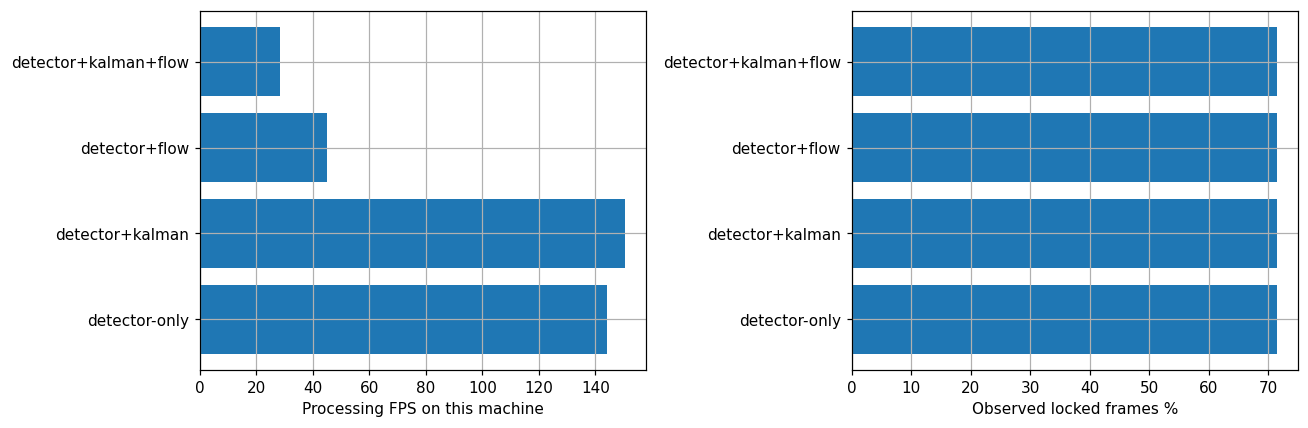

In [3]:
names = [r["algorithm"] for r in reports]
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].barh(names, [r["processing_fps"] for r in reports]); axes[0].set_xlabel("Processing FPS on this machine")
axes[1].barh(names, [r["continuity_percent"] or 0 for r in reports]); axes[1].set_xlabel("Observed locked frames %")
plt.tight_layout(); plt.show()


## Experiment

In [4]:
assert (output / "comparison.csv").is_file()
assert (output / "comparison.json").is_file()
assert all(r["lost_frames"] > 0 for r in reports)
print("Occlusion produced measured lost frames; comparison reports saved in", output)


Occlusion produced measured lost frames; comparison reports saved in notebook_output/comparison


## Observations
The first subject disappears during the scripted sequence, which exercises lost-state handling. All detections are scripted in this demo; replace the source with a real labelled video to study detector and association errors.

## Conclusion
A reproducible performance comparison needs fixed data, parameters, measured timings and clearly bounded claims.